# Agent Middleware in LangChain -- CineBot Hands-On

Middleware gives you a way to **tightly control what happens inside an agent** without touching the
agent's core loop. Instead of stuffing guardrails, retries and logging into your tools and prompts,
you plug small, reusable pieces around the model call and the tool call.

Typical jobs for middleware:

- **Track** agent behaviour -- logging, analytics, debugging
- **Transform** prompts, tool selection and output formatting
- **Harden** the run -- retries, fallbacks, early termination
- **Protect** -- rate limits, guardrails, PII detection
- **Supervise** -- human-in-the-loop approval before risky actions

This notebook walks through every prebuilt middleware using **CineBot**, a movie-ticket assistant,
and finishes with a **real SQLite-backed test bench** that proves two of them (HITL and Summarization)
work against real side effects instead of mocked strings.

> Everything here runs on **Groq's free tier** (`openai/gpt-oss-120b`) -- no paid API needed.
> Reference: `docs/Agent-Middleware-Architecture.pdf` (the whiteboard this notebook follows).

## How middleware plugs into the agent loop

```
Request
  |
  v
before_agent            <- once, when the run starts
  |
  v
+-> before_model        <- runs before every model call
|     |
|     v
|   wrap_model_call     <- wraps the model call itself (retry / fallback / edit the request)
|     |
|     v
|   MODEL
|     |
|     v
|   after_model         <- inspect / gate the model's output (e.g. pause before a tool call)
|     |
|     v
|   wrap_tool_call      <- wraps each tool execution (retry / error handling / emulation)
|     |
|     v
|   TOOL executes -----------+
|                            |
+-------- loop until the model stops calling tools
  |
  v
after_agent             <- once, when the run ends
  |
  v
Response
```

Two rules worth remembering when you stack several middleware in `middleware=[...]`:

1. `before_*` hooks run **first to last**, `after_*` hooks run **last to first**.
2. `wrap_*` hooks **nest** -- the first middleware in the list is the outermost wrapper.

### The prebuilt middleware covered here

The **Hook(s)** column was read from the installed `langchain` package (`langchain 1.3.14`), not guessed.

| Section | Middleware | Hook(s) | What it does |
|--:|-----------|---------|--------------|
| 3 | `SummarizationMiddleware` | `before_model` | Compresses old messages into a summary once history crosses a token/message/fraction trigger |
| 4 | `HumanInTheLoopMiddleware` | `after_model` | Pauses the run before a sensitive tool call so a human can approve / edit / reject / respond |
| 5 | `ModelCallLimitMiddleware` | `before_model`, `after_model` | Caps model calls per run and per thread |
| 6 | `ModelFallbackMiddleware` | `wrap_model_call` | Tries backup models when the primary model call fails |
| 7 | `ToolCallLimitMiddleware` | `after_model` | Caps tool calls -- globally or for one named tool |
| 8 | `PIIMiddleware` | `before_model`, `after_model` | Detects and redacts / masks / hashes / blocks personal data |
| 9 | `TodoListMiddleware` | `wrap_model_call`, `after_model` | Gives the agent a `write_todos` planning tool for multi-step work |
| 10 | `LLMToolSelectorMiddleware` | `wrap_model_call` | Uses a (cheaper) LLM to pre-select the relevant tools before the main model call |
| 11 | `ToolErrorMiddleware` | `wrap_tool_call` | Turns chosen tool exceptions into an error `ToolMessage` the model can react to |
| 12 | `ToolRetryMiddleware` | `wrap_tool_call` | Retries failed tool calls with exponential backoff |
| 13 | `LLMToolEmulator` | `wrap_tool_call` | Replaces real tool execution with an LLM-generated fake result (testing) |

`ModelRetryMiddleware` only appears as a one-line helper in section 9, and `ContextEditingMiddleware` /
`ClearToolUsesEdit` are imported for reference but **not demonstrated yet** -- see the README's "Next steps".

### Notebook map

1. Setup (Groq model, helpers) -> 2. CineBot tools -> 3-13. One section per middleware (numbers in the
table above) -> 14. Real-world test bench (SQLite) -> 15. Takeaways & cheat sheet

Under each demo, a short **"Observed in the saved run"** note explains what the output shows. LLM output
varies between runs, so your own run will differ in wording -- the *behaviour* is what to look for.

## 1. Setup

**Why Groq?** It has a free tier with fast inference, and the repo's `.env` already holds a
`GROQ_API_KEY`. (Google Gemini would also work, but no Gemini key is configured here.)

**Which Groq model?** The notebook was developed against two free models:

| Model | What I saw |
|-------|-----------|
| `openai/gpt-oss-120b` (**used for the saved outputs**) | Fast (whole notebook in ~6 min), no special limits to work around. Occasionally emits a malformed tool call (HTTP 400 `output_parse_failed`) and sometimes replies instead of calling a tool -- normal LLM flakiness that the middleware in this notebook exists to absorb. |
| `qwen/qwen3.8-27b` | Very dependable at tool calling, including the *forced* tool calls that `LLMToolSelectorMiddleware` and structured output rely on. But the free tier is tight: **1,000 output tokens/min** and **200,000 tokens/day** (a handful of full runs used up the day), and it rejects any request that does not declare `max_tokens`. |

Switch models by changing `GROQ_MODEL`; `MODEL_SETTINGS` carries each model's quirks.

**Free-tier limits worth knowing** (read from Groq's own 429 messages / response headers): about 8,000
tokens per minute, 1,000 requests per day, and per-model daily token budgets. Tool schemas are re-sent on
every model call, so a chatty demo can hit a 429 -- `make_model` sets `max_retries=6`, so the Groq client
waits out the `retry-after` header and retries. Limits move without notice; if a cell fails with a 429,
wait a minute and re-run it.

In [1]:
import os
import time

from dotenv import load_dotenv, find_dotenv

load_dotenv(find_dotenv())

GROQ_API_KEY = os.environ.get("GROQ_API_KEY")
assert GROQ_API_KEY, "Missing GROQ_API_KEY -- add it to the .env file at the repo root"

from langchain.chat_models import init_chat_model

GROQ_MODEL = "openai/gpt-oss-120b"

# Per-model settings learned the hard way on Groq's free tier (details in the note above).
MODEL_SETTINGS = {
    "openai/gpt-oss-120b": {"reasoning_effort": "low"},   # reasoning tokens count as output -- keep them small
    "qwen/qwen3.8-27b": {"max_tokens": 800},              # rejects requests that declare no output cap
}


def make_model(model_id: str = GROQ_MODEL, **overrides):
    """Build every model in one place so temperature / retry / per-model settings stay consistent."""
    settings = {
        "temperature": 0,     # deterministic-ish output makes the demos easier to compare
        "max_retries": 6,     # ride out Groq free-tier 429s (the SDK honours retry-after)
        **MODEL_SETTINGS.get(model_id, {}),
        **overrides,
    }
    return init_chat_model(f"groq:{model_id}", api_key=GROQ_API_KEY, **settings)


model = make_model()
print(model.invoke("Reply with exactly: CineBot is online").content)

CineBot is online


### Imports and helpers

`Command` is how you resume a paused (human-in-the-loop) run; `InMemorySaver` is the checkpointer that
makes pausing, resuming and multi-turn memory possible.

In [2]:
# --- Core LangChain ---
from langchain.agents import create_agent
from langchain_core.tools import tool

# --- LangGraph (checkpointing, resuming) ---
from langgraph.checkpoint.memory import InMemorySaver
from langgraph.types import Command

# --- Prebuilt middleware ---
from langchain.agents.middleware import (
    SummarizationMiddleware,
    HumanInTheLoopMiddleware,
    ModelCallLimitMiddleware,
    ToolCallLimitMiddleware,
    ModelFallbackMiddleware,
    PIIMiddleware,
    TodoListMiddleware,
    LLMToolSelectorMiddleware,
    ToolErrorMiddleware,
    ToolRetryMiddleware,
    LLMToolEmulator,
    wrap_model_call,          # decorator for writing your own (custom) middleware
    # Imported for reference, demonstrated in a later iteration:
    ModelRetryMiddleware,
    ContextEditingMiddleware,
    ClearToolUsesEdit,
)

In [3]:
def show(result, width=260, last_turn=False):
    """Compact, readable dump of an agent result (replaces printing the raw state dict).

    last_turn=True prints only the messages since the latest user message (handy on long threads).
    """
    messages = result["messages"]
    if last_turn:
        start = max(i for i, m in enumerate(messages) if type(m).__name__ == "HumanMessage")
        messages = messages[start:]
    for message in messages:
        kind = type(message).__name__.replace("Message", "")
        text = message.content if isinstance(message.content, str) else str(message.content)
        text = " ".join(text.split())
        tag = ""
        if message.additional_kwargs.get("lc_source") == "summarization":
            tag = "  <-- SUMMARY injected by SummarizationMiddleware"
        if len(text) > width:
            text = text[:width] + " ..."
        if text or not getattr(message, "tool_calls", None):
            print(f"[{kind}] {text}{tag}")
        for call in getattr(message, "tool_calls", None) or []:
            print(f"[{kind}] -> tool call: {call['name']}({call['args']})")
    if result.get("__interrupt__"):
        print("[PAUSED] waiting for a human decision (see __interrupt__)")

## 2. CineBot's tools (mocked)

These return canned strings -- fine for learning the *mechanics* of middleware. Section 14 swaps them
for tools backed by a real SQLite database so side effects become verifiable.

Two tools are deliberately special:

- `cancel_booking` -- **irreversible**, so it will sit behind human approval.
- `lookup_seat_map` -- **raises an exception** on a malformed seat number, to exercise error handling.

In [4]:
@tool
def check_showtimes(movie_title: str) -> str:
    """Check available showtimes for a movie at the cinema."""
    fake_showtimes = {
        "interstellar": "7:00 PM and 10:15 PM",
        "dune part two": "9:30 PM only",
        "oppenheimer": "Sold out for tonight",
    }
    return fake_showtimes.get(movie_title.lower(), "No showtimes found for that title.")


@tool
def book_seats(movie_title: str, seat_count: int) -> str:
    """Book seats for a movie. Irreversible once confirmed."""
    return f"Booked {seat_count} seat(s) for {movie_title}."


@tool
def cancel_booking(booking_id: str) -> str:
    """Cancel an existing booking. Irreversible."""
    return f"Booking {booking_id} cancelled."


@tool
def check_order_status(booking_id: str) -> str:
    """Check the status of an existing booking."""
    return f"Booking {booking_id}: confirmed, 2 seats, Interstellar, 7:00 PM."


@tool
def get_refund_policy() -> str:
    """Get the cinema's refund policy -- exact wording, not to be paraphrased."""
    return "Refunds available up to 2 hours before showtime. No refunds after that."


@tool
def lookup_seat_map(movie_title: str, seat_number: str) -> str:
    """Look up a specific seat -- fails if the seat number format is wrong."""
    if not seat_number or not seat_number[0].isalpha():
        raise ValueError(f"Malformed seat number '{seat_number}' -- expected a letter+number like 'A12'.")
    return f"Seat {seat_number} for {movie_title}: available."


cinebot_tools = [check_showtimes, book_seats, cancel_booking, check_order_status, get_refund_policy, lookup_seat_map]
print([t.name for t in cinebot_tools])

['check_showtimes', 'book_seats', 'cancel_booking', 'check_order_status', 'get_refund_policy', 'lookup_seat_map']


## 3. Summarization Middleware

**Problem:** every turn re-sends the whole conversation, so long chats blow past the context window and
cost more. **Fix:** when the history crosses a trigger, replace the old messages with an LLM-written
summary and keep only the most recent ones (`100k tokens -> ~10k`).

| Parameter | Meaning |
|-----------|---------|
| `model` | The model that writes the summary -- can be cheaper/smaller than the main agent |
| `trigger` | When to summarise: `("tokens", N)`, `("messages", N)` or `("fraction", f)`; pass a list to trigger on *any* of them |
| `keep` | What survives verbatim after summarising: `("messages", N)`, `("tokens", N)` or `("fraction", f)` |

Here: *once the history exceeds ~300 tokens, summarise everything except the last message.*
(Deliberately tiny so the demo triggers quickly -- real apps use thousands of tokens.)

> **Multimodal note:** summarization is text-oriented compression. It does not resize or downsample
> image/audio/video payloads. Recent messages kept by `keep` retain their original multimodal blocks;
> older multimodal messages become only the generated text summary. For image-heavy apps, store media
> in a filesystem or object store and pass URLs or file references through the message history.

> **Gotcha -- summariser failures are silent.** If the summary call itself fails (rate limit, outage),
> the middleware does not raise. It swallows the error and injects the text
> `Error generating summary: <error>` **as if it were the summary**, and the old messages are gone.
> The agent keeps running on a corrupted history. I hit exactly this on Groq's free tier: the summariser
> call (on `qwen3.8-27b`, with no `max_tokens` cap) was rejected with a 429, yet the notebook "passed" with
> an error string as its summary. Check for that string in tests -- never trust "the run didn't crash".

### Memory needs a checkpointer

The whiteboard's second lesson: without a checkpointer every `.invoke()` starts from **nothing**; with
`InMemorySaver` + a `thread_id`, the thread's messages accumulate (and summarization has something to
summarise).

In [5]:
summarizing_agent = create_agent(
    model=model,
    tools=cinebot_tools,
    checkpointer=InMemorySaver(),          # remembers the thread between .invoke() calls
    middleware=[
        SummarizationMiddleware(
            model=model,                   # the summariser (could be a cheaper model)
            trigger=("tokens", 300),       # history above ~300 tokens -> summarise
            keep=("messages", 1),          # keep only the most recent message verbatim
        )
    ],
)
sum_cfg = {"configurable": {"thread_id": "summarize-demo"}}

summarizing_agent.invoke({"messages": [("user", "Hi, I am Asha.")]}, config=sum_cfg)
result = summarizing_agent.invoke(
    {"messages": [("user", "Is Interstellar showing tonight? Also book me a ticket, share the refund "
                           "policy for me to go through, and check my order status for BK1234.")]},
    config=sum_cfg,
)
show(result)

summary = next((m for m in result["messages"] if m.additional_kwargs.get("lc_source") == "summarization"), None)
if summary:
    print("\n--- full text of the injected summary ---")
    print(summary.content)

[Human] Here is a summary of the conversation to date: ## SESSION INTENT User wants to know if the movie *Interstellar* is showing tonight, book a ticket for it, receive the refund policy, and check the order status for booking reference BK1234. ## SUMMARY - User iden ...  <-- SUMMARY injected by SummarizationMiddleware
[AI] -> tool call: check_order_status({'booking_id': 'BK1234'})
[Tool] Booking BK1234: confirmed, 2 seats, Interstellar, 7:00 PM.
[AI] **Order status** - **Booking reference:** BK1234 - **Status:** Confirmed - **Tickets:** 2 seats - **Movie:** *Interstellar* - **Showtime:** 7:00 PM (today) **Cinema refund policy (exact wording):** *“Refunds are available up to 2 hours before the showtime; no  ...

--- full text of the injected summary ---
Here is a summary of the conversation to date:

## SESSION INTENT
User wants to know if the movie *Interstellar* is showing tonight, book a ticket for it, receive the refund policy, and check the order status for booking reference BK12

**Observed in the saved run:** the history crossed the 300-token trigger, so the older messages were replaced
by the summary (the message flagged `lc_source == "summarization"`, printed in full above). What the model
works from is now *summary + newest messages*, not the raw turns. The summary kept the user's name (**Asha**),
the four things they asked for, and a list of next steps.

In [6]:
# The earlier turns are now compressed. Can the agent still remember who I am?
result = summarizing_agent.invoke({"messages": [("user", "Who am I?")]}, config=sum_cfg)
show(result)

[Human] Here is a summary of the conversation to date: ## SESSION INTENT User (Asha) wants to book a ticket for the movie *Interstellar* tonight, confirm showtimes, receive the refund policy, and check the order status for booking reference BK1234. ## SUMMARY - User i ...  <-- SUMMARY injected by SummarizationMiddleware
[Human] Who am I?
[AI] You are **Asha**.


**Observed:** "Who am I?" is answered from the summary alone -- the original "Hi, I am Asha." message no
longer exists in the history, yet the fact survived.

**Contrast -- no checkpointer, no memory.** Same question, but each `.invoke()` is an isolated run.

In [7]:
stateless_agent = create_agent(model=model, tools=cinebot_tools)   # no checkpointer

stateless_agent.invoke({"messages": [("user", "Hi, I am Asha.")]})
result = stateless_agent.invoke({"messages": [("user", "Who am I?")]})
show(result)

[Human] Who am I?
[AI] I’m sorry, but I don’t have enough information to know who you are. If you’d like to share more about yourself or let me know how I can help, feel free to do so!


**Observed:** with no checkpointer the agent has no idea. Memory comes from the checkpointer;
summarization only keeps that memory affordable.

## 4. Human-in-the-Loop (HITL) Middleware

Gives a human **oversight over risky tool calls**. When the model decides to call a guarded tool, the
run **pauses** (an *interrupt*), a human decides, and the run resumes.

```
User  --"Send an email asking for leave"-->  LLM  --decides to call-->  send_email_tool
                                                                              |
                                                                       requires approval
                                                                              v
                                                                         INTERRUPT
                                                                              |
                                          +-----------------+-----------------+----------------+
                                          v                 v                                  v
                                       approve            edit                              reject
                                     send as-is     change the tool args                  don't send
```

`interrupt_on` maps **tool name -> config**: `False` means "never pause for this tool",
and a dict with `allowed_decisions` means "pause and offer these choices".

| Decision | Resume payload | Effect |
|----------|----------------|--------|
| `approve` | `{"type": "approve"}` | Run the tool exactly as proposed |
| `edit` | `{"type": "edit", "edited_action": {"name": ..., "args": {...}}}` | Run the tool with the human's arguments |
| `reject` | `{"type": "reject", "message": "why"}` | Skip the tool; the reason goes back to the model |
| `respond` | `{"type": "respond", "message": "answer"}` | Skip the tool; the human's text becomes its result |

> A **checkpointer is mandatory** -- the paused state has to be saved somewhere so the run can resume.

### 4a. Minimal example: an intern that must ask before sending email

In [8]:
def read_email_tool(email_id: str) -> str:
    """Mock function to read an email by its ID."""
    return f"Email content for ID: {email_id}"


def send_email_tool(recipient: str, subject: str, body: str) -> str:
    """Mock function to send an email."""
    return f"Email sent to {recipient} with subject '{subject}'"


email_agent = create_agent(
    model=model,
    tools=[read_email_tool, send_email_tool],
    checkpointer=InMemorySaver(),
    middleware=[
        HumanInTheLoopMiddleware(
            interrupt_on={
                "send_email_tool": {"allowed_decisions": ["approve", "edit", "reject"]},
                "read_email_tool": False,      # harmless -> never pause
            }
        ),
    ],
)
email_cfg = {"configurable": {"thread_id": "hitl-email-approve"}}

result = email_agent.invoke(
    {"messages": [("user", "Send an email to my manager at manager@example.com asking for leave tomorrow.")]},
    config=email_cfg,
)
show(result)
request = result["__interrupt__"][0].value["action_requests"][0]
print("\nPaused on:", request["name"])
print("Proposed args:", request["args"])

[Human] Send an email to my manager at manager@example.com asking for leave tomorrow.
[AI] -> tool call: send_email_tool({'body': 'Dear Manager,\n\nI would like to request a leave for tomorrow. Please let me know if any further information is needed.\n\nThank you,\n[Your Name]', 'recipient': 'manager@example.com', 'subject': 'Leave Request for Tomorrow'})
[PAUSED] waiting for a human decision (see __interrupt__)

Paused on: send_email_tool
Proposed args: {'body': 'Dear Manager,\n\nI would like to request a leave for tomorrow. Please let me know if any further information is needed.\n\nThank you,\n[Your Name]', 'recipient': 'manager@example.com', 'subject': 'Leave Request for Tomorrow'}


**Observed:** the run stopped *before* `send_email_tool` executed (`[PAUSED]`). The interrupt carries the
exact call the model proposed. Nothing has been sent yet.

In [9]:
# A human approves -> the paused tool call now actually runs.
resumed = email_agent.invoke(Command(resume={"decisions": [{"type": "approve"}]}), config=email_cfg)
show(resumed)

[Human] Send an email to my manager at manager@example.com asking for leave tomorrow.
[AI] -> tool call: send_email_tool({'body': 'Dear Manager,\n\nI would like to request a leave for tomorrow. Please let me know if any further information is needed.\n\nThank you,\n[Your Name]', 'recipient': 'manager@example.com', 'subject': 'Leave Request for Tomorrow'})
[Tool] Email sent to manager@example.com with subject 'Leave Request for Tomorrow'
[AI] Your email requesting leave for tomorrow has been sent to your manager. Let me know if there’s anything else you need!


**Observed:** only now does the tool run -- the `Tool` message appears and the model writes its answer.

**`edit`** -- same agent, new thread. The human keeps the action but changes its arguments before it
executes. Models often leave placeholders like `[Your Name]` in drafts, so the natural human edit is to
fill that in before the email goes out.

In [10]:
edit_cfg = {"configurable": {"thread_id": "hitl-email-edit"}}

paused = email_agent.invoke(
    {"messages": [("user", "Send an email to my manager at manager@example.com asking for leave tomorrow.")]},
    config=edit_cfg,
)
proposed = paused["__interrupt__"][0].value["action_requests"][0]
print("Model proposed:", proposed["name"], proposed["args"])

resumed = email_agent.invoke(
    Command(resume={"decisions": [{
        "type": "edit",
        "edited_action": {"name": proposed["name"],
                          "args": {**proposed["args"], "body": proposed["args"]["body"].replace("[Your Name]", "Asha")}},
    }]}),
    config=edit_cfg,
)
show(resumed)

Model proposed: send_email_tool {'body': 'Dear Manager,\n\nI would like to request a leave for tomorrow. Please let me know if any further information is needed.\n\nThank you,\n[Your Name]', 'recipient': 'manager@example.com', 'subject': 'Leave Request for Tomorrow'}


[Human] Send an email to my manager at manager@example.com asking for leave tomorrow.
[AI] -> tool call: send_email_tool({'body': 'Dear Manager,\n\nI would like to request a leave for tomorrow. Please let me know if any further information is needed.\n\nThank you,\nAsha', 'recipient': 'manager@example.com', 'subject': 'Leave Request for Tomorrow'})
[Tool] Email sent to manager@example.com with subject 'Leave Request for Tomorrow'
[AI] Your email requesting leave for tomorrow has been sent to your manager. Let me know if there’s anything else you need!


**Observed:** the call recorded in history is the **edited** one -- the body now ends with `Asha` instead of the
model's `[Your Name]` placeholder -- and that edited version is what executed. The model never saw its
original arguments run.

### 4b. CineBot: guard `cancel_booking`

Now the same idea on CineBot. `cancel_booking` allows all four decisions; every other tool runs freely.
After the first `.invoke()` we can inspect the **paused graph state** with `get_state(config)`:
`state.next` names the node waiting to continue, and `state.tasks[0].interrupts` holds what the human
is being asked to review.

In [11]:
def build_guarded_agent():
    return create_agent(
        model=model,
        tools=cinebot_tools,
        middleware=[
            HumanInTheLoopMiddleware(
                interrupt_on={"cancel_booking": {"allowed_decisions": ["approve", "edit", "reject", "respond"]}}
            ),
        ],
        checkpointer=InMemorySaver(),   # REQUIRED -- HITL needs to pause and later resume
    )


guarded_agent = build_guarded_agent()
config = {"configurable": {"thread_id": "hitl-cinebot-reject"}}

result = guarded_agent.invoke({"messages": [("user", "Please cancel booking BK1042")]}, config=config)
state = guarded_agent.get_state(config)
print("state.next      :", state.next)
print("interrupt value :", state.tasks[0].interrupts[0].value)

state.next      : ('HumanInTheLoopMiddleware.after_model',)
interrupt value : {'action_requests': [{'name': 'cancel_booking', 'args': {'booking_id': 'BK1042'}, 'description': "Tool execution requires approval\n\nTool: cancel_booking\nArgs: {'booking_id': 'BK1042'}"}], 'review_configs': [{'action_name': 'cancel_booking', 'allowed_decisions': ['approve', 'edit', 'reject', 'respond']}]}


**Observed:** `state.next` names the node the graph is parked on (`HumanInTheLoopMiddleware.after_model`).
The interrupt value has two parts: `action_requests` (what will run) and `review_configs` (which decisions
the human may choose from).

In [12]:
# Reject -> the tool never runs and the model is told why.
rejected = guarded_agent.invoke(
    Command(resume={"decisions": [{"type": "reject", "message": "Not authorised -- the customer did not ask for this."}]}),
    config=config,
)
show(rejected)

[Human] Please cancel booking BK1042
[AI] -> tool call: cancel_booking({'booking_id': 'BK1042'})
[Tool] Not authorised -- the customer did not ask for this.
[AI] I’m happy to help with that, but I’ll need to confirm that you’d like to cancel booking **BK1042**. Please let me know if you’d like to proceed with the cancellation.


**Observed:** the `Tool` message is the human's *reason*, not a tool result -- `cancel_booking` never ran.
The model reads that reason and reports back.

### 4c. An interactive approval loop

`run_interactive_hitl_demo` shows how a real UI would drive the four decisions. It normally asks with
`input()`; passing `answers=[...]` scripts the replies so this notebook can run unattended. Approve, edit
and reject were shown above, so the scripted run below uses **`respond`**: the human answers *on the
tool's behalf* and the real tool never executes.

> Code walkthrough: `Command(resume={"decisions": [...]})` hands a decision back to an agent paused
> mid-run. The `decisions` list has **one entry per interrupted tool call** (usually just one). Each
> decision is a dict whose `"type"` is one of the four options, plus whatever extra data that type needs.

In [13]:
def run_interactive_hitl_demo(agent, config, answers=None):
    """Ask a human how to handle the paused tool call, then resume the agent.

    Uses input() normally. Pass answers=[...] to script the replies (keeps the notebook runnable headless).
    """
    replies = iter(answers) if answers is not None else None

    def ask(prompt):
        if replies is None:
            return input(prompt).strip()
        reply = next(replies)
        print(f"{prompt}{reply}")
        return reply

    state = agent.get_state(config)
    if not state.next:
        print("Nothing is currently paused for approval.")
        return
    pending = state.tasks[0].interrupts[0].value["action_requests"][0]

    print(f"The agent wants to call {pending['name']}({pending['args']}). Choose a decision:")
    print("  1) approve  -- run it exactly as proposed")
    print("  2) edit     -- run it, but change the booking_id first")
    print("  3) reject   -- block it, with a reason sent back to the agent")
    print("  4) respond  -- answer on the tool's behalf instead of running it")

    choice = ask("Type 1, 2, 3, or 4: ")
    if choice == "1":
        decision = {"type": "approve"}
    elif choice == "2":
        new_id = ask("New booking_id to use instead: ")
        decision = {"type": "edit",
                    "edited_action": {"name": pending["name"], "args": {**pending["args"], "booking_id": new_id}}}
    elif choice == "3":
        decision = {"type": "reject", "message": ask("Reason for rejecting: ")}
    elif choice == "4":
        decision = {"type": "respond", "message": ask("Your response to the agent: ")}
    else:
        print("Not a valid choice -- try again.")
        return

    resumed = agent.invoke(Command(resume={"decisions": [decision]}), config=config)
    print()
    print("Agent's final response:", resumed["messages"][-1].content)
    return resumed

In [14]:
config2 = {"configurable": {"thread_id": "hitl-cinebot-edit"}}
guarded_agent.invoke({"messages": [("user", "Please cancel booking BK1042")]}, config=config2)

# Scripted human: choose 4 (respond) -- answer on the tool's behalf, so the cancellation never runs.
_ = run_interactive_hitl_demo(
    guarded_agent, config2,
    answers=["4", "Cancellations need manager sign-off. Request logged; it will be processed within 24 hours."],
)

The agent wants to call cancel_booking({'booking_id': 'BK1042'}). Choose a decision:
  1) approve  -- run it exactly as proposed
  2) edit     -- run it, but change the booking_id first
  3) reject   -- block it, with a reason sent back to the agent
  4) respond  -- answer on the tool's behalf instead of running it
Type 1, 2, 3, or 4: 4
Your response to the agent: Cancellations need manager sign-off. Request logged; it will be processed within 24 hours.



Agent's final response: Your cancellation request for booking **BK1042** has been logged. A manager will review and approve the cancellation, and you’ll receive a confirmation within the next 24 hours. If you have any other questions in the meantime, just let me know!


**Observed (`respond`):** the human's sentence became the tool's result and the real tool never executed. Note
the difference from `reject`: a rejection says "don't do that"; a response says "here is the answer".

## 5. Model Call Limit

Guardrail against runaway loops and surprise bills: cap how many times the **model** may be called.

| Parameter | Scope | Analogy from the whiteboard |
|-----------|-------|-----------------------------|
| `run_limit` | A single `.invoke()` | chapatis allowed **per meal** |
| `thread_limit` | The whole conversation (all invokes on one `thread_id`) | chapatis allowed **total across all meals** |
| `exit_behavior` | `"end"` stops gracefully with a message; `"error"` raises an exception | |

`thread_limit` only works with a checkpointer, since something has to remember the running count.
The values below are deliberately tiny for the demo. A tool round-trip costs two model calls (decide to
call the tool, then write the answer), so a `run_limit` of 2 leaves no room for anything more complex.

In [15]:
call_limited_agent = create_agent(
    model=model,
    tools=cinebot_tools,
    checkpointer=InMemorySaver(),          # required so thread_limit persists across calls
    middleware=[
        ModelCallLimitMiddleware(
            thread_limit=5,                # across the WHOLE conversation
            run_limit=2,                   # per single .invoke() call
            exit_behavior="end",           # graceful stop, not an exception
        ),
    ],
)
limit_cfg = {"configurable": {"thread_id": "call-limit-demo"}}

questions = [
    "Can you tell me the cinema's refund policy?",
    "Cancel my booking B123.",
    "What movies are being shown?",
    "Summarize my chat.",
]
for i, question in enumerate(questions, 1):
    print(f"\n=== invoke {i}: {question}")
    result = call_limited_agent.invoke({"messages": [("user", question)]}, config=limit_cfg)
    show(result, width=200, last_turn=True)


=== invoke 1: Can you tell me the cinema's refund policy?


[Human] Can you tell me the cinema's refund policy?
[AI] -> tool call: get_refund_policy({'': {}})
[Tool] Refunds available up to 2 hours before showtime. No refunds after that.
[AI] Refunds available up to 2 hours before showtime. No refunds after that.

=== invoke 2: Cancel my booking B123.


[Human] Cancel my booking B123.
[AI] -> tool call: cancel_booking({'booking_id': 'B123'})
[Tool] Booking B123 cancelled.
[AI] Your booking **B123** has been cancelled.

=== invoke 3: What movies are being shown?


[Human] What movies are being shown?
[AI] I’m sorry, but I don’t have access to the current list of movies being shown at the cinema. You can check the cinema’s website or contact them directly for the most up‑to‑date schedule.

=== invoke 4: Summarize my chat.
[Human] Summarize my chat.
[AI] Model call limits exceeded: thread limit (5/5)


**Observed:** invokes 1 and 2 each cost two model calls (decide to call the tool, then answer) = 4; invoke 3
needed one more = 5; invoke 4 was stopped before any model call: `Model call limits exceeded: thread limit
(5/5)`. `run_limit=2` never triggered here because no single invoke needed more than 2 -- `thread_limit` did.
(The odd `get_refund_policy({'': {}})` arguments are this model's quirk for a no-argument tool; the call still
works.)

With `exit_behavior="error"` the same limit raises instead of ending quietly -- useful when a limit breach
should fail a job loudly:

In [16]:
strict_agent = create_agent(
    model=model,
    tools=cinebot_tools,
    middleware=[ModelCallLimitMiddleware(run_limit=1, exit_behavior="error")],
)
try:
    strict_agent.invoke({"messages": [("user", "What is the refund policy?")]})
except Exception as exc:
    print(type(exc).__name__, "->", exc)

ModelCallLimitExceededError -> Model call limits exceeded: run limit (1/1)


**Observed:** the first model call is allowed; as soon as a second is needed (after the tool result) the run
raises `ModelCallLimitExceededError` instead of ending quietly.

## 6. Model Fallback

If the primary model call fails (outage, rate limit, retired model), quietly try the next model in the
chain instead of failing the user's request. `ModelFallbackMiddleware(first, *more)` takes fallbacks in
priority order.

To trigger a failure on demand we point the primary at a **model that does not exist**.

In [17]:
BAD_MODEL = "groq:qwen/this-model-does-not-exist"   # simulates an outage / retired model

# Without middleware the failure reaches the caller.
plain_agent = create_agent(model=BAD_MODEL, tools=cinebot_tools)
try:
    plain_agent.invoke({"messages": [("user", "What is the refund policy?")]})
except Exception as exc:
    print("WITHOUT fallback ->", type(exc).__name__, ":", str(exc)[:160])

WITHOUT fallback -> NotFoundError : Error code: 404 - {'error': {'message': 'The model `qwen/this-model-does-not-exist` does not exist or you do not have access to it.', 'type': 'invalid_request_e


**Observed:** without middleware, the provider's 404 reaches the caller and the request fails.

In [18]:
resilient_agent = create_agent(
    model=BAD_MODEL,                                   # primary -- broken on purpose
    tools=cinebot_tools,
    middleware=[
        ModelFallbackMiddleware(
            model,                                     # 1st fallback: the working Groq model
            # "ollama:llama3.2",                       # a further, fully-local last resort -- needs
            #                                          # `pip install langchain-ollama` + a local Ollama server
        ),
    ],
)
result = resilient_agent.invoke({"messages": [("user", "What is the refund policy?")]})
print("WITH fallback:")
show(result)

WITH fallback:
[Human] What is the refund policy?
[AI] -> tool call: get_refund_policy({'': {}})
[Tool] Refunds available up to 2 hours before showtime. No refunds after that.
[AI] Refunds available up to 2 hours before showtime. No refunds after that.


**Observed:** same broken primary, but the failed call was retried on the fallback model and the user got a
normal answer. The caller never saw an error.

Middleware become part of the agent's compiled graph. Rendering it needs network access to
mermaid.ink, so the cell falls back to text if that is blocked.

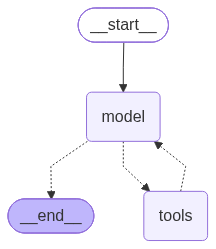

In [19]:
graph = resilient_agent.get_graph()
try:
    from IPython.display import Image, display
    display(Image(graph.draw_mermaid_png()))
except Exception as exc:
    print(f"(PNG render unavailable: {type(exc).__name__}) -- graph nodes instead:")
    print(list(graph.nodes))

## 7. Tool Call Limit

Same `run_limit` / `thread_limit` idea as section 5, but for **tool** calls -- and it can target either
**all tools** or **one specific tool**. You can stack several instances:

- `ToolCallLimitMiddleware(run_limit=8)` -- at most 8 tool calls of any kind per invoke.
- `ToolCallLimitMiddleware(tool_name="cancel_booking", thread_limit=2, run_limit=1)` -- a tighter cap on
  the dangerous tool: 1 cancellation per invoke, 2 across the whole conversation.

`exit_behavior` defaults to `"continue"`: over-limit calls are blocked with an error message the model
sees, and the run carries on (other tools still work).

Below we ask for three cancellations, one per invoke, on the same thread. Expect the third to be blocked
by `thread_limit=2`.

In [20]:
tool_limited_agent = create_agent(
    model=model,
    tools=cinebot_tools,
    checkpointer=InMemorySaver(),
    middleware=[
        ToolCallLimitMiddleware(run_limit=8),                                              # global, this invoke
        ToolCallLimitMiddleware(tool_name="cancel_booking", thread_limit=2, run_limit=1),  # one tool, tighter
    ],
)
tool_cfg = {"configurable": {"thread_id": "tool-limit-demo"}}

for i in range(3):
    print(f"\n=== invoke {i + 1}: cancel B{100 + i}")
    result = tool_limited_agent.invoke(
        {"messages": [("user", f"Please cancel my booking with ID B{100 + i}.")]}, config=tool_cfg
    )
    show(result, width=200, last_turn=True)


=== invoke 1: cancel B100


[Human] Please cancel my booking with ID B100.
[AI] -> tool call: cancel_booking({'booking_id': 'B100'})
[Tool] Booking B100 cancelled.
[AI] Your booking with ID **B100** has been successfully cancelled. If you have any other requests or need further assistance, feel free to let me know!

=== invoke 2: cancel B101


[Human] Please cancel my booking with ID B101.
[AI] -> tool call: cancel_booking({'booking_id': 'B101'})
[Tool] Booking B101 cancelled.
[AI] Your booking **B101** has been cancelled. Let me know if there’s anything else I can help with!

=== invoke 3: cancel B102


[Human] Please cancel my booking with ID B102.
[AI] -> tool call: cancel_booking({'booking_id': 'B102'})
[Tool] Tool call limit exceeded. Do not call 'cancel_booking' again.
[AI] I’m sorry—I’m unable to process any more cancellation requests directly at the moment. If you need to cancel booking **B102**, please reach out to the cinema’s customer‑service team (e.g., via phone,  ...


**Observed:** invokes 1 and 2 cancelled normally. In invoke 3 the middleware blocked the call and put
`Tool call limit exceeded. Do not call 'cancel_booking' again.` in the tool result, so the model explained the
limitation instead of cancelling. `run_limit=1` never mattered (one cancel per invoke); the thread-wide
`thread_limit=2` did.

## 8. PII Detection

Guardrail for **personally identifiable information**. `PIIMiddleware(pii_type, strategy=...)` scans
messages and applies one of four strategies:

| Strategy | Result for `priya@example.com` / a card number |
|----------|------------------------------------------------|
| `redact` | Replaced by a placeholder such as `[REDACTED_EMAIL]` |
| `mask` | Partially hidden, e.g. only the last four digits of a card remain (`****-****-****-1111`) |
| `hash` | Replaced by a deterministic hash (lets you correlate without revealing) |
| `block` | Raises `PIIDetectionError` -- the run is rejected |

Built-in detectors: `email`, `credit_card`, `ip`, `mac_address`, `url`. Anything else -- like CineBot's
own booking codes, or India's Aadhaar / PAN numbers from the whiteboard -- needs a **custom detector**,
either a function returning `[{"text", "start", "end"}, ...]` or a regex string, e.g.
`PIIMiddleware("aadhaar", detector=r"\b\d{4}\s?\d{4}\s?\d{4}\b", strategy="hash")`.

> **Gotcha -- the credit-card detector validates the Luhn checksum.** A made-up number such as
> `4111-1111-1111-1234` *looks* like a card but fails Luhn, so it is silently **not** detected and passes
> straight through to the model. Use a valid test number (`4111-1111-1111-1111`) when demoing.

By default it checks the **input** (`apply_to_input=True`); `apply_to_output` and `apply_to_tool_results`
extend it to the model's replies and tool outputs.

In [21]:
pii_agent = create_agent(
    model=model,
    tools=cinebot_tools,
    middleware=[
        PIIMiddleware("email", strategy="redact", apply_to_input=True),
        PIIMiddleware("credit_card", strategy="mask", apply_to_input=True),
    ],
)
result = pii_agent.invoke({
    "messages": [("user", "My email is priya@example.com and my credit card is 4111-1111-1111-1111, "
                          "can you check showtimes for Dune Part Two?")]
})
show(result)

[Human] My email is [REDACTED_EMAIL] and my credit card is ****-****-****-1111, can you check showtimes for Dune Part Two?
[AI] -> tool call: check_showtimes({'movie_title': 'Dune Part Two'})
[Tool] 9:30 PM only
[AI] Here are the available showtimes for **“Dune Part Two”** at our cinema: - **9:30 PM** (today) Let me know if you’d like to book tickets for this showing, check other dates/times, or need any further assistance!


**Observed:** the message the model received -- and the one stored in history -- is already scrubbed:
`[REDACTED_EMAIL]` and `****-****-****-1111`. The raw values never reached the model.

### Custom detector: CineBot booking codes (`BK` + 4 digits)

In [22]:
import re


def detect_booking_code(content: str) -> list[dict]:
    """Detect CineBot's own booking code format: BK followed by 4 digits."""
    return [
        {"text": m.group(0), "start": m.start(), "end": m.end()}
        for m in re.finditer(r"BK\d{4}", content)
    ]


custom_pii_agent = create_agent(
    model=model,
    tools=cinebot_tools,
    middleware=[PIIMiddleware("booking_code", detector=detect_booking_code, strategy="mask")],
)
result = custom_pii_agent.invoke({"messages": [("user", "Can you check the status of my booking BK1044 for me?")]})
show(result)

[Human] Can you check the status of my booking ****1044 for me?
[AI] -> tool call: check_order_status({'booking_id': '****1044'})
[Tool] Booking ****1044: confirmed, 2 seats, Interstellar, 7:00 PM.
[AI] Your booking ******1044** is confirmed. It includes 2 seats for **Interstellar** at **7:00 PM**. Let me know if you’d like to make any changes or need anything else!


**Observed -- masking has a cost.** The model received `****1044` and passed exactly that to
`check_order_status`. The mock tool doesn't care, but a real lookup by booking ID would fail. Mask what the
model must not see; do not mask identifiers that tools need to look things up.

## 9. To-Do List Middleware

Adds a **`write_todos`** planning tool (plus matching instructions) so the agent can break a complex,
multi-step request into a task list and tick items off as it goes. The list lives in agent state under
the `todos` key. For simple one-step requests the model is told *not* to bother.

The agent below also carries a one-line **`ModelRetryMiddleware`**. `gpt-oss` on Groq occasionally emits a
malformed tool call, which the API rejects with HTTP 400 (`output_parse_failed`); re-asking the model
almost always fixes it. It is the model-side twin of `ToolRetryMiddleware` (section 12) and takes the same
`max_retries` / `backoff_factor` / `on_failure` knobs.

In [23]:
todo_agent = create_agent(
    model=model,
    tools=cinebot_tools,
    middleware=[
        TodoListMiddleware(),
        ModelRetryMiddleware(max_retries=3),   # retry a flaky model call (e.g. Groq's output_parse_failed)
    ],
)
result = todo_agent.invoke({
    "messages": [("user", "Plan my movie night. Use your todo list to track the steps: (1) check showtimes for "
                          "Interstellar, Dune Part Two and Oppenheimer, (2) pick one that is not sold out, "
                          "(3) book 2 seats for it, (4) tell me the refund policy.")]
})
show(result)
print("\nFinal todo list held in agent state:")
for item in result.get("todos", []):
    print(f"  [{item['status']}] {item['content']}")

[Human] Plan my movie night. Use your todo list to track the steps: (1) check showtimes for Interstellar, Dune Part Two and Oppenheimer, (2) pick one that is not sold out, (3) book 2 seats for it, (4) tell me the refund policy.
[AI] -> tool call: write_todos({'todos': [{'content': 'Check showtimes for Interstellar', 'status': 'in_progress'}, {'content': 'Check showtimes for Dune Part Two', 'status': 'pending'}, {'content': 'Check showtimes for Oppenheimer', 'status': 'pending'}, {'content': 'Pick a movie with available seats', 'status': 'pending'}, {'content': 'Book 2 seats for the selected movie', 'status': 'pending'}, {'content': "Retrieve the cinema's refund policy", 'status': 'pending'}]})
[Tool] Updated todo list to [{'content': 'Check showtimes for Interstellar', 'status': 'in_progress'}, {'content': 'Check showtimes for Dune Part Two', 'status': 'pending'}, {'content': 'Check showtimes for Oppenheimer', 'status': 'pending'}, {'content': 'Pick a movi ...
[AI] -> tool call: check_

**Observed:** the agent called `write_todos` up front and again as steps finished; the list lives in
`result["todos"]`. It also rewrote the list mid-way (dropping items already done) and left the last item
`in_progress` when it answered. The middleware provides the planning *tool*, not the discipline to keep the
list tidy.

## 10. LLM Tool Selector

**Problem:** agents with dozens of tools waste tokens describing every tool on every call and get worse
at choosing. **Fix:** before the main model call, a (cheaper) LLM picks only the relevant tools.

- `max_tools` -- how many tools to pass through
- `always_include` -- tools that are always kept and don't count against `max_tools`
- `model` -- the selector model; can be cheaper than the agent's

To *see* the effect we also write a tiny **custom middleware** with the `@wrap_model_call` decorator.
It sits **after** the selector in the list, so it observes the already-filtered tool list.

In [24]:
@wrap_model_call
def show_tools(request, handler):
    print("TOOLS SENT TO MODEL:", [t.name for t in request.tools])
    return handler(request)


selector_agent = create_agent(
    model=model,
    tools=cinebot_tools,
    middleware=[
        LLMToolSelectorMiddleware(
            model=model,                         # can be a CHEAPER model than the main agent
            max_tools=2,
            always_include=["check_showtimes"],  # always kept, doesn't count against max_tools
        ),
        show_tools,                              # custom middleware: prints what the main model actually sees
    ],
)
print("All tools available:", [t.name for t in cinebot_tools], "\n")
result = selector_agent.invoke({"messages": [("user", "Can you cancel my booking with ID B1234?")]})
show(result)

All tools available: ['check_showtimes', 'book_seats', 'cancel_booking', 'check_order_status', 'get_refund_policy', 'lookup_seat_map'] 



TOOLS SENT TO MODEL: ['cancel_booking', 'check_showtimes']


TOOLS SENT TO MODEL: ['cancel_booking', 'check_showtimes']


[Human] Can you cancel my booking with ID B1234?
[AI] -> tool call: cancel_booking({'booking_id': 'B1234'})
[Tool] Booking B1234 cancelled.
[AI] Your booking with ID **B1234** has been successfully cancelled. If you need any further assistance, feel free to let me know!


**Observed:** out of 6 tools the main model was offered only 2 -- the selector's pick (`cancel_booking`) plus
the `always_include` tool (`check_showtimes`). `TOOLS SENT TO MODEL` printed twice because the run made two model
calls (before and after the tool result) and the filter runs on each.

## 11. Tool Error Middleware

When a tool raises, you choose what happens. `ToolErrorMiddleware(on_error=handler)` calls your handler
with the exception; **return a string** and it becomes an error `ToolMessage` the model can recover from,
**return `None`** and the exception propagates and halts the run. Handling is opt-in per exception type.

Prefer returning the **exception type** rather than `str(exc)` -- raw messages can leak internal detail
to the model or end user.

`lookup_seat_map("...", "12")` raises `ValueError` (a seat must start with a letter). First, no middleware:

In [25]:
plain_agent = create_agent(model=model, tools=cinebot_tools)
try:
    result = plain_agent.invoke({"messages": [("user", "Look up seat 12 for Dune Part Two")]})
    show(result)
except Exception as exc:
    print("WITHOUT ToolErrorMiddleware the run crashed ->", type(exc).__name__, ":", exc)

WITHOUT ToolErrorMiddleware the run crashed -> ValueError : Malformed seat number '12' -- expected a letter+number like 'A12'.


**Observed:** the tool's `ValueError` escapes `.invoke()` and crashes the run.

In [26]:
def on_seat_error(exc: Exception, request) -> str | None:
    if isinstance(exc, ValueError):
        # Return the EXCEPTION TYPE, not str(exc) -- internal detail never reaches the model
        return f"`{request.tool_call['name']}` failed with {type(exc).__name__}. Please provide a valid seat number like 'A12'."
    return None  # anything else propagates and halts the run


error_handled_agent = create_agent(
    model=model,
    tools=cinebot_tools,
    middleware=[ToolErrorMiddleware(on_error=on_seat_error)],
)
result = error_handled_agent.invoke({"messages": [("user", "Look up seat 12 for Dune Part Two")]})
print("WITH ToolErrorMiddleware:")
show(result)

WITH ToolErrorMiddleware:
[Human] Look up seat 12 for Dune Part Two
[AI] -> tool call: lookup_seat_map({'movie_title': 'Dune Part Two', 'seat_number': '12'})
[Tool] `lookup_seat_map` failed with ValueError. Please provide a valid seat number like 'A12'.
[AI] I’m sorry, but the seat number you provided isn’t in the correct format. Could you please give the seat identifier in the usual format (for example, “A12”, “B5”, etc.)?


**Observed:** the exception became a `ToolMessage` naming only the exception *type*
(`failed with ValueError`) -- no internal message -- and the model recovered by asking the user for a valid
seat number.

## 12. Tool Retry Middleware

For **transient** failures (network blips, timeouts) it is better to retry than to bother the model.
`ToolRetryMiddleware` re-runs a failed tool with **exponential backoff**:

```
delay = initial_delay * backoff_factor ** retry_number       (capped by max_delay, +/- jitter)
```

With `initial_delay=1.0, backoff_factor=2.0` the waits before retries 1, 2, 3 are:

In [27]:
initial_delay, backoff_factor = 1.0, 2.0
for retry_number in range(3):
    print(f"retry {retry_number + 1}: {initial_delay} * {backoff_factor} ** {retry_number} = {initial_delay * backoff_factor ** retry_number:.0f}s")

retry 1: 1.0 * 2.0 ** 0 = 1s
retry 2: 1.0 * 2.0 ** 1 = 2s
retry 3: 1.0 * 2.0 ** 2 = 4s


`on_failure` decides what happens when retries run out: `"continue"` hands the error to the model as a
`ToolMessage` (the run goes on), `"error"` re-raises.

The tool below is instrumented -- it prints each attempt and the gap since the previous one, so the
backoff is visible. `jitter=False` keeps the gaps exact for the demo (in production leave jitter on so
many clients don't retry in lock-step).

**Scenario A -- transient failure:** fails twice, succeeds on the 3rd attempt. The model never notices.

In [28]:
def make_flaky_tool(fail_times: int):
    """A showtime tool that raises ConnectionError for its first `fail_times` calls, then works."""
    state = {"calls": 0, "last": None}

    @tool
    def flaky_showtime_check(movie_title: str) -> str:
        """Check showtimes via an external service that can transiently fail."""
        now = time.time()
        gap = f"+{now - state['last']:.1f}s" if state["last"] else "first attempt"
        state["calls"], state["last"] = state["calls"] + 1, now
        if state["calls"] <= fail_times:
            print(f"  attempt {state['calls']} ({gap}): ConnectionError")
            raise ConnectionError("Simulated network failure -- exactly what a real external call risks.")
        print(f"  attempt {state['calls']} ({gap}): OK")
        return f"{movie_title}: showing at 8:00 PM."

    return flaky_showtime_check


retry = ToolRetryMiddleware(max_retries=3, backoff_factor=2.0, initial_delay=1.0, jitter=False, on_failure="continue")

transient_agent = create_agent(model=model, tools=[make_flaky_tool(fail_times=2)], middleware=[retry])
result = transient_agent.invoke({"messages": [("user", "Check showtimes for Interstellar")]})
show(result)

  attempt 1 (first attempt): ConnectionError


  attempt 2 (+1.0s): ConnectionError


  attempt 3 (+2.0s): OK


[Human] Check showtimes for Interstellar
[AI] -> tool call: flaky_showtime_check({'movie_title': 'Interstellar'})
[Tool] Interstellar: showing at 8:00 PM.
[AI] Here are the showtimes for **Interstellar**: - **8:00 PM**. Enjoy the movie!


**Observed:** attempts 1 and 2 failed, with waits of exactly 1.0 s and 2.0 s (the backoff table above);
attempt 3 succeeded. The model only ever saw the final success.

**Scenario B -- persistent outage:** the tool never recovers. After 1 try + 3 retries the middleware gives
up, and because `on_failure="continue"` the model receives the error and can tell the user.

In [29]:
outage_agent = create_agent(model=model, tools=[make_flaky_tool(fail_times=99)], middleware=[retry])
result = outage_agent.invoke({"messages": [("user", "Check showtimes for Interstellar")]})
show(result)

  attempt 1 (first attempt): ConnectionError


  attempt 2 (+1.0s): ConnectionError


  attempt 3 (+2.0s): ConnectionError


  attempt 4 (+4.0s): ConnectionError


  attempt 5 (+0.7s): ConnectionError


  attempt 6 (+1.0s): ConnectionError


  attempt 7 (+2.0s): ConnectionError


  attempt 8 (+4.0s): ConnectionError


[Human] Check showtimes for Interstellar
[AI] -> tool call: flaky_showtime_check({'movie_title': 'Interstellar'})
[Tool] Tool 'flaky_showtime_check' failed after 4 attempts with ConnectionError: Simulated network failure -- exactly what a real external call risks.. Please try again.
[AI] -> tool call: flaky_showtime_check({'movie_title': 'Interstellar'})
[Tool] Tool 'flaky_showtime_check' failed after 4 attempts with ConnectionError: Simulated network failure -- exactly what a real external call risks.. Please try again.
[AI] I’m sorry—I wasn’t able to retrieve the showtime information for **Interstellar** due to repeated connection problems with the external service. If you’d like, you can try checking again in a few minutes, or let me know a specific theater or city you’re intere ...


**Observed:** attempts 1-4 (1 try + 3 retries) with gaps of 1, 2 and 4 s, then the middleware gave up and
returned an error string as the tool result (`on_failure="continue"`). This model then **called the tool again
itself**, producing attempts 5-8 before apologising. The middleware caps *its own* retries; it cannot stop the
model from trying again. If that matters, pair it with `ToolCallLimitMiddleware`.

## 13. LLM Tool Emulator

For **testing**: instead of running a tool, an LLM *imagines* a plausible result. Handy for exercising an
agent's flow before the real tools (or their side effects) exist -- no bookings are made, no email is sent.

- `tools=[...]` -- emulate only these tools (others run for real); omit to emulate **all** tools
- `model=` -- the emulator model. **Always pass it explicitly**: the default is
  `anthropic:claude-sonnet-4-5-20250929`, which would demand an Anthropic API key.

In [30]:
emulated_agent = create_agent(
    model=model,
    tools=cinebot_tools,
    middleware=[LLMToolEmulator(tools=["book_seats", "cancel_booking"], model=model)],
)
result = emulated_agent.invoke({"messages": [("user", "Book 2 seats for Interstellar tonight at 7:00 PM. Go ahead and book them now.")]})
show(result)

[Human] Book 2 seats for Interstellar tonight at 7:00 PM. Go ahead and book them now.
[AI] -> tool call: book_seats({'movie_title': 'Interstellar', 'seat_count': 2})
[Tool] { "status": "success", "booking_id": "INT-20230921-8427", "movie_title": "Interstellar", "seat_count": 2, "message": "Your seats have been booked successfully." }
[AI] Your booking is confirmed! **Booking Details** - **Movie:** Interstellar - **Showtime:** Tonight at 7:00 PM - **Seats Booked:** 2 - **Booking ID:** `INT-20230921-8427` If you need anything else—such as checking the booking status, looking up seat numbers, or l ...


**Observed:** `book_seats` never executed -- the real mock would have returned `Booked 2 seat(s) for
Interstellar.` Instead the emulator LLM invented a JSON body with a booking ID, and the agent carried on as
if it were real.

Emulating **all** tools (the default). `get_weather` below only returns `"Weather in <city>"`, yet the
emulated result can invent temperatures -- proof the real function body never ran.

In [31]:
@tool
def get_weather(location: str) -> str:
    """Get the current weather for a location."""
    return f"Weather in {location}"


@tool
def send_email(to: str, subject: str, body: str) -> str:
    """Send an email."""
    return "Email sent"


emulate_all_agent = create_agent(
    model=model,
    tools=[get_weather, send_email],
    middleware=[LLMToolEmulator(model=model)],       # tools=None -> emulate everything
)
result = emulate_all_agent.invoke({
    "messages": [("user", "Please email manager@example.com asking for leave tomorrow, mentioning the weather in Gurgaon.")]
})
show(result)

[Human] Please email manager@example.com asking for leave tomorrow, mentioning the weather in Gurgaon.
[AI] -> tool call: get_weather({'location': 'Gurgaon'})
[Tool] { "location": "Gurgaon", "temperature": "31°C", "condition": "Partly cloudy", "humidity": "48%", "wind_speed": "12 km/h", "forecast": "Clear skies later in the evening" }
[AI] -> tool call: send_email({'body': 'Dear Manager,\n\nI would like to request a leave for tomorrow. The weather in Gurgaon is currently 31°C and partly cloudy, which I hope will be conducive for any necessary arrangements.\n\nThank you for your understanding.\n\nBest regards,\n[Your Name]', 'subject': 'Leave Request for Tomorrow', 'to': 'manager@example.com'})
[Tool] { "status": "success", "messageId": "20260921-7f9c3b2a-4d1e-11ef-8c3a-0242ac130003", "timestamp": "2026-09-21T14:32:07Z", "to": "manager@example.com", "subject": "Leave Request for Tomorrow", "preview": "Dear Manager,\n\nI would like to request a leave for tom ...
[AI] The email has been s

**Observed:** both tools were emulated. The real `get_weather` only ever returns `"Weather in Gurgaon"`, so the
temperature, humidity and forecast in the tool result are pure invention -- proof the function body never ran.

## 14. Real-world test bench: SQLite-backed refund approver

Everything above is a **mock** -- every tool just returns an f-string and nothing is ever stored or
changed. That is fine for learning middleware *mechanics*, but it hides the two things that matter once
this goes into a real app:

1. **`HumanInTheLoopMiddleware`** only proves itself when the gated tool has a **real, verifiable side
   effect** -- you want to see the write did *not* happen while paused, and *did* happen only after approval.
2. **`SummarizationMiddleware`** only proves itself when the context is **genuinely large** and the agent
   has to recall a fact from the generated summary rather than from raw history still sitting right there.

A real SQLite database (`cinema.db`, a file next to this notebook) backs `check_booking`, `list_bookings`,
`cancel_booking_live` and `issue_refund_live`. We read the database **directly, outside the agent**, to
prove HITL blocks/unblocks a write, and we seed enough rows to force a real summarization trigger.

> `cinema.db` is regenerated (and its rows reset) every time the next cell runs, and is git-ignored.

In [32]:
import sqlite3
from pathlib import Path

DB_PATH = Path("cinema.db")


def get_conn():
    return sqlite3.connect(DB_PATH)


def fetch_rows():
    conn = get_conn()
    rows = conn.execute(
        "SELECT booking_id, customer, movie_title, seats, amount_paid, status FROM bookings ORDER BY booking_id"
    ).fetchall()
    conn.close()
    return rows


def init_db():
    conn = get_conn()
    conn.execute("""
        CREATE TABLE IF NOT EXISTS bookings (
            booking_id TEXT PRIMARY KEY,
            customer TEXT NOT NULL,
            movie_title TEXT NOT NULL,
            seats INTEGER NOT NULL,
            amount_paid REAL NOT NULL,
            status TEXT NOT NULL DEFAULT 'confirmed'
        )
    """)
    conn.execute("DELETE FROM bookings")  # fresh slate every run
    movies = ["Interstellar", "Dune Part Two", "Oppenheimer", "Inception"] * 10
    seed = [
        (f"BK{1000 + i}", f"customer_{i % 5}", movie, (i % 4) + 1, 12.5 * ((i % 4) + 1), "confirmed")
        for i, movie in enumerate(movies)
    ]
    conn.executemany("INSERT INTO bookings VALUES (?, ?, ?, ?, ?, ?)", seed)
    conn.commit()
    conn.close()


def inspect_db(limit=None):
    """Read the DB directly, bypassing the agent entirely -- this is ground truth."""
    rows = fetch_rows()
    for r in rows[:limit]:
        print(r)
    if limit and len(rows) > limit:
        print(f"... ({len(rows) - limit} more rows)")
    return rows


init_db()
print(f"Seeded {len(fetch_rows())} real rows into {DB_PATH.resolve().name}")
_ = inspect_db(limit=3)

Seeded 40 real rows into cinema.db
('BK1000', 'customer_0', 'Interstellar', 1, 12.5, 'confirmed')
('BK1001', 'customer_1', 'Dune Part Two', 2, 25.0, 'confirmed')
('BK1002', 'customer_2', 'Oppenheimer', 3, 37.5, 'confirmed')
... (37 more rows)


In [33]:
@tool
def check_booking(booking_id: str) -> str:
    """Look up a real booking by ID from the live database."""
    conn = get_conn()
    row = conn.execute(
        "SELECT customer, movie_title, seats, amount_paid, status FROM bookings WHERE booking_id = ?",
        (booking_id,),
    ).fetchone()
    conn.close()
    if not row:
        return f"No booking found with ID {booking_id}."
    customer, movie_title, seats, amount_paid, status = row
    return f"{booking_id}: {customer}, {movie_title}, {seats} seat(s), ${amount_paid:.2f} paid, status={status}"


@tool
def list_bookings() -> str:
    """List every real booking currently in the database."""
    return "\n".join(
        f"{bid}: {cust}, {movie}, {seats} seat(s), ${amt:.2f}, {status}"
        for bid, cust, movie, seats, amt, status in fetch_rows()
    )


@tool
def cancel_booking_live(booking_id: str) -> str:
    """Cancel a REAL booking -- writes to the database. Irreversible without a manual DB edit."""
    conn = get_conn()
    cur = conn.execute(
        "UPDATE bookings SET status = 'cancelled' WHERE booking_id = ? AND status = 'confirmed'",
        (booking_id,),
    )
    conn.commit()
    changed = cur.rowcount
    conn.close()
    if not changed:
        return f"Could not cancel {booking_id} -- not found or not in 'confirmed' status."
    return f"Booking {booking_id} cancelled in the live database."


@tool
def issue_refund_live(booking_id: str) -> str:
    """Refund a REAL cancelled booking -- zeroes amount_paid in the database. Irreversible."""
    conn = get_conn()
    cur = conn.execute(
        "UPDATE bookings SET amount_paid = 0 WHERE booking_id = ? AND status = 'cancelled'",
        (booking_id,),
    )
    conn.commit()
    changed = cur.rowcount
    conn.close()
    if not changed:
        return f"Could not refund {booking_id} -- must be cancelled first."
    return f"Booking {booking_id} refunded in the live database."


live_tools = [check_booking, list_bookings, cancel_booking_live, issue_refund_live]

### 14a. HITL against real writes -- proof, not narration

The system prompt tells the model to call the tool directly (HITL already provides the approval step, so
the model asking again would be redundant). Then we check the database at every stage.

In [34]:
live_guarded_agent = create_agent(
    model=model,
    tools=live_tools,
    system_prompt=(
        "You are a cinema booking assistant. When the user asks to cancel a booking or "
        "issue a refund, call the relevant tool directly and immediately -- do not ask the "
        "user for confirmation yourself. A human-in-the-loop approval step already runs "
        "automatically before the tool executes, so asking your own confirmation question "
        "first is redundant and should be skipped."
    ),
    middleware=[
        HumanInTheLoopMiddleware(
            interrupt_on={
                "cancel_booking_live": {"allowed_decisions": ["approve", "edit", "reject"]},
                "issue_refund_live": {"allowed_decisions": ["approve", "edit", "reject"]},
            }
        ),
    ],
    checkpointer=InMemorySaver(),
)


def db_status(booking_id):
    return next(r for r in fetch_rows() if r[0] == booking_id)


print("BEFORE any tool call, BK1000 in the DB:", db_status("BK1000"))

live_config = {"configurable": {"thread_id": "live-refund-demo"}}
result = live_guarded_agent.invoke({"messages": [("user", "Cancel booking BK1000, please.")]}, config=live_config)

print("\nAgent paused?      ", bool(result.get("__interrupt__")))
print("AFTER invoke, while paused -- DB must be UNCHANGED:", db_status("BK1000"))

BEFORE any tool call, BK1000 in the DB: ('BK1000', 'customer_0', 'Interstellar', 1, 12.5, 'confirmed')



Agent paused?       True
AFTER invoke, while paused -- DB must be UNCHANGED: ('BK1000', 'customer_0', 'Interstellar', 1, 12.5, 'confirmed')


**Observed:** the agent paused for approval and the row in SQLite is still `confirmed`. That is ground truth
read straight from the file, not from anything the agent said.

In [35]:
rejected = live_guarded_agent.invoke(
    Command(resume={"decisions": [{"type": "reject", "message": "Not authorized -- customer didn't request this."}]}),
    config=live_config,
)
if rejected.get("__interrupt__"):
    print("Agent after reject: it proposed the cancellation AGAIN and paused for approval again (nothing has run).")
else:
    print("Agent after reject:", " ".join(rejected["messages"][-1].content.split())[:300])
print("\nAFTER reject -- DB must STILL be unchanged. This is the real payoff of HITL:", db_status("BK1000"))

Agent after reject: it proposed the cancellation AGAIN and paused for approval again (nothing has run).

AFTER reject -- DB must STILL be unchanged. This is the real payoff of HITL: ('BK1000', 'customer_0', 'Interstellar', 1, 12.5, 'confirmed')


**Observed:** after the rejection the row is *still* `confirmed`. Note that this model responded by proposing
the cancellation again, which paused it again -- a rejection is feedback to the model, not a hard stop, so the
gate must keep holding on every attempt (it did).

In [36]:
live_config2 = {"configurable": {"thread_id": "live-refund-demo-2"}}
live_guarded_agent.invoke({"messages": [("user", "Cancel booking BK1000, please.")]}, config=live_config2)

approved = live_guarded_agent.invoke(Command(resume={"decisions": [{"type": "approve"}]}), config=live_config2)
print("Agent after approve:", " ".join(approved["messages"][-1].content.split())[:300])
print("\nAFTER approve -- DB must show BK1000 as cancelled for real:", db_status("BK1000"))

Agent after approve: Your booking **BK1000** has been successfully cancelled. If you’d like a refund or need any further assistance, just let me know!

AFTER approve -- DB must show BK1000 as cancelled for real: ('BK1000', 'customer_0', 'Interstellar', 1, 12.5, 'cancelled')


**Observed:** after approval the row flips to `cancelled` in the database file. Same tool, same request; the
only difference is the human decision.

### 14b. Summarization against a real, large context

`list_bookings` returns every row in the DB -- with 40 seeded rows that is a genuinely large tool result,
big enough to trip `trigger=("tokens", 300)` for real (not the single-message toy case from section 3).

The test that matters: after summarization compresses the early turns, can the agent still answer a
question about a specific booking it only ever saw in that big tool result? `recall_test` checks three
independent things instead of trusting the answer:

1. **Did the summary succeed?** (not the silent `Error generating summary` failure from section 3)
2. **Did the summary keep the fact?** (does it contain BK1010's id *and* its amount -- the id alone is not
   enough, because the user's own question gets folded into later summaries too)
3. **Did the agent have to call a tool again** to answer?

The test uses `keep=("messages", 1)` on purpose. With `keep=2` the assistant's *own* turn-1 answer -- a table
of all 40 bookings -- survives verbatim as a "recent message", so the agent can answer from it and the
summary is never exercised. (The original version of this test had exactly that flaw.) Keeping only the
newest message forces the table to be summarised away too.

> The original version of this test had **no checkpointer**, so the second question never saw the first
> turn at all. `InMemorySaver` + a fixed `thread_id` is what makes it a real recall test.

In [37]:
def recall_test(thread_id, summary_prompt=None):
    """Turn 1 lists every booking (big tool result). Turn 2 asks about BK1010 after summarization has fired."""
    extra = {"summary_prompt": summary_prompt} if summary_prompt else {}
    agent = create_agent(
        model=model,
        tools=live_tools,
        system_prompt=(
            "You are a cinema booking assistant. If the answer is already in the conversation so far "
            "(including a summary of it), answer from that -- only call a tool when you genuinely lack the information."
        ),
        checkpointer=InMemorySaver(),
        middleware=[SummarizationMiddleware(model=model, trigger=("tokens", 300), keep=("messages", 1), **extra)],
    )
    cfg = {"configurable": {"thread_id": thread_id}}
    agent.invoke({"messages": [("user", "List every booking in the system right now.")]}, config=cfg)
    result = agent.invoke(
        {"messages": [("user", "Of everything you just listed, what's the status and amount paid for BK1010 specifically?")]},
        config=cfg,
    )

    msgs = result["messages"]
    summary = next((m for m in msgs if m.additional_kwargs.get("lc_source") == "summarization"), None)
    after = msgs[msgs.index(summary) + 1:] if summary else msgs
    print("Agent's answer                    :", " ".join(msgs[-1].content.split()))
    print("Ground truth (DB)                 :", db_status("BK1010")[3:], "<- seats, amount_paid, status")
    print("Summarization fired               :", summary is not None)
    print("Summary generated OK (no error)   :", bool(summary) and "Error generating summary" not in summary.content)
    print("Summary keeps BK1010's row (id+$) :", bool(summary) and "BK1010" in summary.content and "37.5" in summary.content)
    print("Tool calls made after the summary :", [c["name"] for m in after for c in getattr(m, "tool_calls", None) or []])
    if summary:
        print("\n--- the summary the model actually works from ---")
        print(summary.content[:900] + (" ..." if len(summary.content) > 900 else ""))
    return result


print("Real DB row for BK1010:", db_status("BK1010"))

Real DB row for BK1010: ('BK1010', 'customer_0', 'Oppenheimer', 3, 37.5, 'confirmed')


**Run A -- default summary prompt.** The default prompt asks for *session intent / summary / artifacts /
next steps*: good for continuity, but it describes data rather than preserving it.

In [38]:
_ = recall_test("live-summarize-default")

Agent's answer                    : Here are the details for booking **BK1010**: - **Customer:** customer_0 - **Movie:** Oppenheimer - **Seats:** 3 - **Amount Paid:** **$37.50** - **Status:** **confirmed**
Ground truth (DB)                 : (3, 37.5, 'confirmed') <- seats, amount_paid, status
Summarization fired               : True
Summary generated OK (no error)   : True
Summary keeps BK1010's row (id+$) : False
Tool calls made after the summary : ['check_booking']

--- the summary the model actually works from ---
Here is a summary of the conversation to date:

## SESSION INTENT
User wants to know the status and amount paid for booking BK1010.

## SUMMARY
- User previously received a full list of bookings (BK1000‑BK1039) with details.
- User now asks specifically for the status and amount paid for booking BK1010.

## ARTIFACTS
None

## NEXT STEPS
Retrieve the details for booking BK1010 (status and amount paid) and provide them to the user.


**Observed (default prompt):** the summary kept the *intent* but none of the 40 rows
(`Summary keeps BK1010's row: False`), so the agent had to call `check_booking` to recover the answer. Correct
in the end -- but through a tool call, not through memory.

**Run B -- a custom `summary_prompt`.** You control *what survives* by replacing the prompt (it must keep the
`{messages}` placeholder). Here we tell the summariser to keep one compact line per booking.
The reply is kept short on purpose: the free tier allows only 1,000 output tokens per minute.

In [39]:
BOOKING_SUMMARY_PROMPT = """You are compressing a cinema-assistant conversation to save context space.
Write a short summary, then copy EVERY booking that appears below in one compact line each, exactly as:
<booking id>: <status>, $<amount paid>
Those exact values will be asked about later, so do not round, merge, or skip any booking.

Messages to summarize:
{messages}
"""

time.sleep(60)   # let Groq's per-minute token budget refill after run A
_ = recall_test("live-summarize-custom", summary_prompt=BOOKING_SUMMARY_PROMPT)

Agent's answer                    : **Booking BK1010** - **Status:** confirmed - **Amount paid:** $37.50
Ground truth (DB)                 : (3, 37.5, 'confirmed') <- seats, amount_paid, status
Summarization fired               : True
Summary generated OK (no error)   : True
Summary keeps BK1010's row (id+$) : True
Tool calls made after the summary : []

--- the summary the model actually works from ---
Here is a summary of the conversation to date:

**Summary:** The user asked for a list of every booking in the system. The system returned 40 bookings ranging from BK1000 to BK1039, each with a customer, movie, seat count, amount paid, and status (cancelled or confirmed).

**Bookings:**
BK1000: cancelled, $12.50  
BK1001: confirmed, $25.00  
BK1002: confirmed, $37.50  
BK1003: confirmed, $50.00  
BK1004: confirmed, $12.50  
BK1005: confirmed, $25.00  
BK1006: confirmed, $37.50  
BK1007: confirmed, $50.00  
BK1008: confirmed, $12.50  
BK1009: confirmed, $25.00  
BK1010: confirmed, $37.50

**Observed (custom prompt):** the summary now carries one compact line per booking, so BK1010 is answered
with **no** tool call (`Tool calls made after the summary: []`), and the answer matches the database. Same
middleware, same trigger -- only the `summary_prompt` changed.

## 15. Takeaways & cheat sheet

- **HITL is only doing real work when there is a real write behind the gated tool.** The before/after
  database checks are the whole point: reject leaves the row untouched, approve actually flips `status` in
  a file on disk. With the mocked `cancel_booking`, "approve" and "reject" just print different strings,
  so you cannot tell the middleware did anything.
- **Summarization is only doing real work when the trigger is crossed by real content and a later turn
  depends on a fact that got summarised away.** `list_bookings()` on a 40-row table is enough real text to
  cross `trigger=("tokens", 300)`; the BK1010 recall question then tests whether the summary preserved
  what the agent needs, not just whether the call ran without erroring.
- **Summarization is lossy by design.** The default summary prompt *describes* data (patterns, counts)
  rather than *preserving* row-level facts. When specific values must survive, supply your own
  `summary_prompt` -- and test recall by inspecting the summary text, not just the final answer.
- **Summariser failures are silent.** A failed summary call becomes the text `Error generating summary: ...`
  instead of an exception, so assert on that string in tests.
- **State needs a checkpointer.** HITL, `thread_limit` and multi-turn memory all silently depend on it.

| Need | Reach for | Key knobs |
|------|-----------|-----------|
| Long conversations, big context | `SummarizationMiddleware` | `trigger`, `keep`, cheaper `model` |
| Approval before risky actions | `HumanInTheLoopMiddleware` | `interrupt_on`, `allowed_decisions`, checkpointer |
| Stop runaway agents / cost | `ModelCallLimitMiddleware`, `ToolCallLimitMiddleware` | `run_limit`, `thread_limit`, `tool_name`, `exit_behavior` |
| Survive model outages | `ModelFallbackMiddleware` | ordered list of backup models |
| Keep personal data out of the model | `PIIMiddleware` | `strategy`, custom `detector`, `apply_to_*` |
| Multi-step planning | `TodoListMiddleware` | (none -- adds `write_todos`) |
| Many tools, few relevant | `LLMToolSelectorMiddleware` | `max_tools`, `always_include` |
| Tools that throw | `ToolErrorMiddleware` | `on_error` handler, `tools` filter |
| Flaky external calls | `ToolRetryMiddleware` | `max_retries`, `backoff_factor`, `on_failure` |
| Test without side effects | `LLMToolEmulator` | `tools`, explicit `model` |

### Where this shows up in production

**Fraud detection in fintech:** a `wrap_tool_call` hook around every transaction-executing tool,
flagging or blocking based on velocity, amount or pattern -- the same shape as `ToolCallLimitMiddleware`,
aimed at fraud instead of booking abuse.

**Healthcare AI assistants:** `PIIMiddleware`-style redaction is often a genuine *legal* requirement
(HIPAA in the US) -- it is the difference between compliant and non-compliant software.

**Customer support platforms:** `HumanInTheLoopMiddleware`-style approval gates before any action with
real financial consequence (refunds, account changes) -- exactly the shape used to guard
`cancel_booking_live` here.

**Internal developer tools:** audit logging via a custom `wrap_tool_call` is close to universal wherever
"who did what, when" needs a real answer -- compliance, debugging or plain accountability.